# Internet Advertisements Data Set

## Data Set Information:

This dataset represents a set of possible advertisements on Internet pages. The features encode the geometry of the image (if available) as well as phrases occuring in the URL, the image's URL and alt text, the anchor text, and words occuring near the anchor text. The task is to predict whether an image is an advertisement ("ad") or not ("nonad"). Additional information can be found [here](https://archive.ics.uci.edu/ml/datasets/internet%2Badvertisements).

## Attribute Information:

The dataset has 3 continous (height, width, aratio) and 1555 binary (urls, tags, captions) features. 

## Source:

Creator & donor: Nicholas Kushmerick <nick '@' ucd.ie>

# Learning Objectives
- Identify and impute missing data
- Use normalization as part of the modeling process: min max normalization.
- Use normalization as part of the modeling process: centering and scaling.
- Use hold-out validation to compare the performance of a pair of models using a large data set.

In [1]:
import pandas as pd

# Load the data
internetAd = pd.read_csv('Internet_Ad_Data.csv', sep=',', error_bad_lines=False)
print(internetAd.info())

/tmp/ipykernel_22456/3629771685.py:4: FutureWarning: The error_bad_lines argument has been deprecated and will be removed in a future version. Use on_bad_lines in the future.


  internetAd = pd.read_csv('Internet_Ad_Data.csv', sep=',', error_bad_lines=False)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3279 entries, 0 to 3278
Columns: 1559 entries, height to Target
dtypes: int64(1554), object(5)
memory usage: 39.0+ MB
None


/tmp/ipykernel_22456/3629771685.py:4: DtypeWarning: Columns (3) have mixed types. Specify dtype option on import or set low_memory=False.
  internetAd = pd.read_csv('Internet_Ad_Data.csv', sep=',', error_bad_lines=False)


In [2]:
internetAd.head(20)

,height,width,aratio,local,url*images+buttons,url*likesbooks.com,url*www.slake.com,url*hydrogeologist,url*oso,url*media,...,caption*home,caption*my,caption*your,caption*in,caption*bytes,caption*here,caption*click,caption*for,caption*you,Target
0,125,125,1.0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,ad.
1,57,468,8.2105,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,ad.
2,33,230,6.9696,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,ad.
3,60,468,7.8,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,ad.
4,60,468,7.8,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,ad.
5,60,468,7.8,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,ad.
6,59,460,7.7966,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,ad.
7,60,234,3.9,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,ad.
8,60,468,7.8,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,ad.
9,60,468,7.8,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,ad.


Question 1.1: Replace all the values of '   ?' with nan. And replace ad. with 1 and nonad. with 0

In [3]:
import numpy as np
#Replace ?
internetAd = internetAd.replace({"ad.":1,"nonad.":0})
internetAd = internetAd.replace(regex="\?$",value=np.NAN)

Question 1.1 Part 2: Check that replacing worked

In [4]:
internetAd.head(20)

,height,width,aratio,local,url*images+buttons,url*likesbooks.com,url*www.slake.com,url*hydrogeologist,url*oso,url*media,...,caption*home,caption*my,caption*your,caption*in,caption*bytes,caption*here,caption*click,caption*for,caption*you,Target
0,125,125,1.0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
1,57,468,8.2105,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
2,33,230,6.9696,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
3,60,468,7.8,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
4,60,468,7.8,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
5,60,468,7.8,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
6,59,460,7.7966,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
7,60,234,3.9,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
8,60,468,7.8,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
9,60,468,7.8,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1


Make Sure that "height","width","aratio" is type - float

In [5]:
internetAd.dtypes

height                object
width                 object
aratio                object
local                 object
url*images+buttons     int64
                       ...  
caption*here           int64
caption*click          int64
caption*for            int64
caption*you            int64
Target                 int64
Length: 1559, dtype: object

In [6]:
internetAd["height"]=internetAd["height"].astype(float)
internetAd["width"]=internetAd["width"].astype(float)
internetAd["aratio"]=internetAd["aratio"].astype(float)

internetAd.head(20)

,height,width,aratio,local,url*images+buttons,url*likesbooks.com,url*www.slake.com,url*hydrogeologist,url*oso,url*media,...,caption*home,caption*my,caption*your,caption*in,caption*bytes,caption*here,caption*click,caption*for,caption*you,Target
0,125.0,125.0,1.0000,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
1,57.0,468.0,8.2105,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
2,33.0,230.0,6.9696,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
3,60.0,468.0,7.8000,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
4,60.0,468.0,7.8000,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
5,60.0,468.0,7.8000,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
6,59.0,460.0,7.7966,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
7,60.0,234.0,3.9000,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
8,60.0,468.0,7.8000,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
9,60.0,468.0,7.8000,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1


In [7]:
internetAd.dtypes

height                float64
width                 float64
aratio                float64
local                  object
url*images+buttons      int64
                       ...   
caption*here            int64
caption*click           int64
caption*for             int64
caption*you             int64
Target                  int64
Length: 1559, dtype: object

Question 1.2: Describe the statistics for each of the columns ["height","width","aratio","local"] 

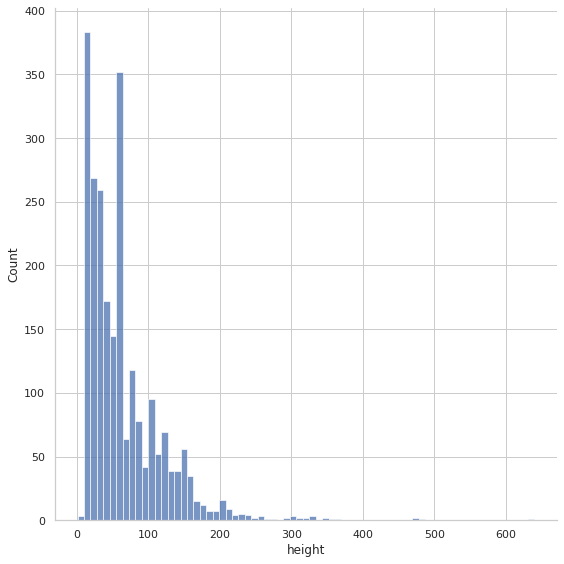

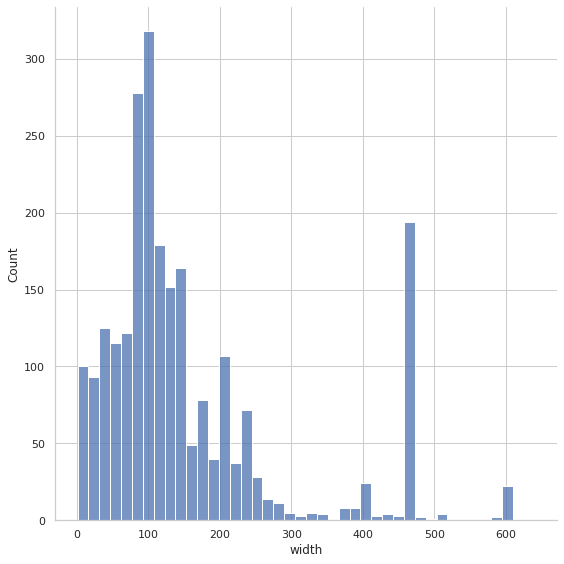

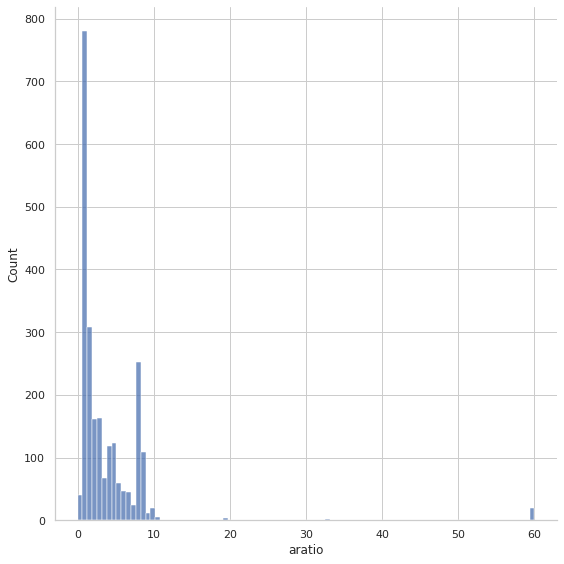

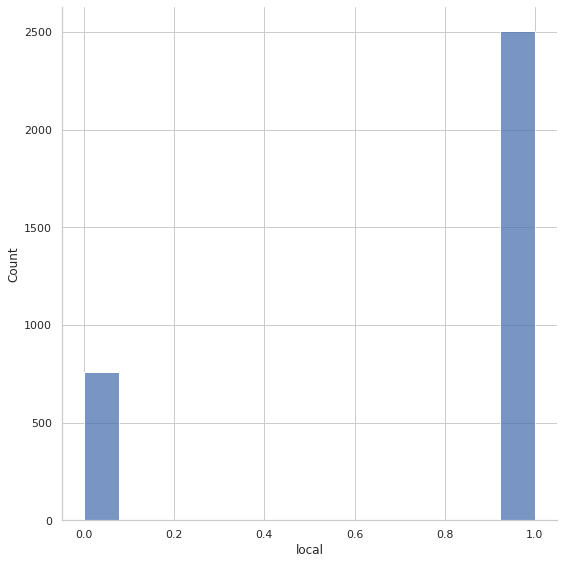

In [8]:
import seaborn as sns
sns.set_theme(style="whitegrid")
sns.displot(internetAd, x=internetAd.height, height=8)
sns.displot(internetAd, x=internetAd.width, height=8)
sns.displot(internetAd, x=internetAd.aratio, height=8)
internetAd["local"]=internetAd["local"].astype(float)
sns.displot(internetAd, x=internetAd.local, height=8);

Question 2.1: Caluclate and display the (mean, median, mode) for each of the columns ["height","width","aratio","local"] as well as the overall statistics using describe method.

In [9]:
#Mean
means = np.mean(internetAd[["height","width","aratio","local"]],axis=0)
print("\t means\n",means)

	 means
 height     64.021886
width     155.344828
aratio      3.911953
local       0.767157
dtype: float64


In [10]:
#Median
medians = np.nanmedian(internetAd[["height","width","aratio","local"]],axis=0)
print("\tmedians\nheight\t{0}\n width\t{1}\naratio\t{2}\nlocal\t{3}".format(medians[0],medians[1],medians[2],medians[3]))

	medians
height	51.0
 width	110.0
aratio	2.102
local	1.0


In [11]:
#Mode
from scipy import stats as st
modes = list(st.mode(internetAd[["height","width","aratio","local"]],nan_policy="omit")[0][0])
print("\tmodes\nheight\t{0}\n width\t{1}\naratio\t{2}\nlocal\t{3}".format(modes[0],modes[1],modes[2],modes[3]))

	modes
height	60.0
 width	468.0
aratio	1.0
local	1.0


In [12]:
print("\t overall statistics")
internetAd[["height","width","aratio","local"]].describe()

	 overall statistics


,height,width,aratio,local
count,2376.000000,2378.000000,2369.000000,3264.000000
mean,64.021886,155.344828,3.911953,0.767157
std,54.868604,130.032350,6.042986,0.422708
min,1.000000,1.000000,0.001500,0.000000
25%,25.000000,80.000000,1.035700,1.000000
50%,51.000000,110.000000,2.102000,1.000000
75%,85.250000,184.000000,5.333300,1.000000
max,640.000000,640.000000,60.000000,1.000000


Question 2.2: Replace nan values for each of the ["height","width","aratio","local"] with the respective median value

In [13]:
internetAd = internetAd.fillna(value={"height":means[0],"width":means[1],"aratio":means[2],"local":means[3]})
internetAd.head(20)

,height,width,aratio,local,url*images+buttons,url*likesbooks.com,url*www.slake.com,url*hydrogeologist,url*oso,url*media,...,caption*home,caption*my,caption*your,caption*in,caption*bytes,caption*here,caption*click,caption*for,caption*you,Target
0,125.000000,125.000000,1.000000,1.0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
1,57.000000,468.000000,8.210500,1.0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
2,33.000000,230.000000,6.969600,1.0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
3,60.000000,468.000000,7.800000,1.0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
4,60.000000,468.000000,7.800000,1.0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
5,60.000000,468.000000,7.800000,1.0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
6,59.000000,460.000000,7.796600,1.0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
7,60.000000,234.000000,3.900000,1.0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
8,60.000000,468.000000,7.800000,1.0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
9,60.000000,468.000000,7.800000,1.0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1


Question 3.1: Plot the distribution of each of ["height","width","aratio","local"]

In [14]:
internetAd[["height","width","aratio","local"]].describe()

,height,width,aratio,local
count,3279.000000,3279.000000,3279.000000,3279.000000
mean,64.021886,155.344828,3.911953,0.767157
std,46.703695,110.729038,5.136153,0.421740
min,1.000000,1.000000,0.001500,0.000000
25%,32.500000,90.000000,1.279400,1.000000
50%,64.021886,150.000000,3.911953,1.000000
75%,64.021886,155.344828,3.911953,1.000000
max,640.000000,640.000000,60.000000,1.000000


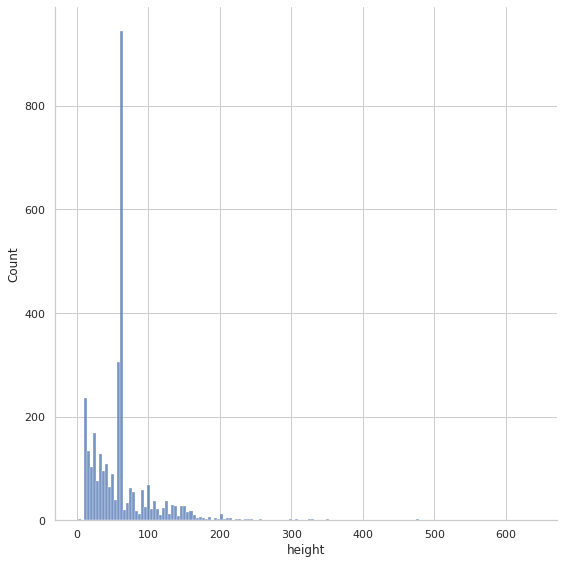

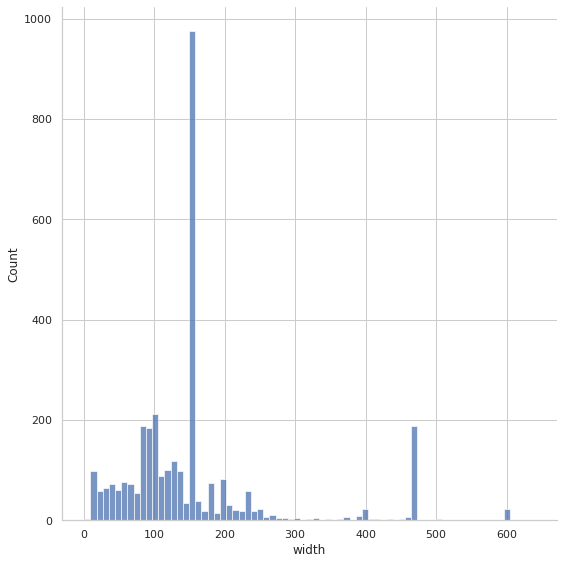

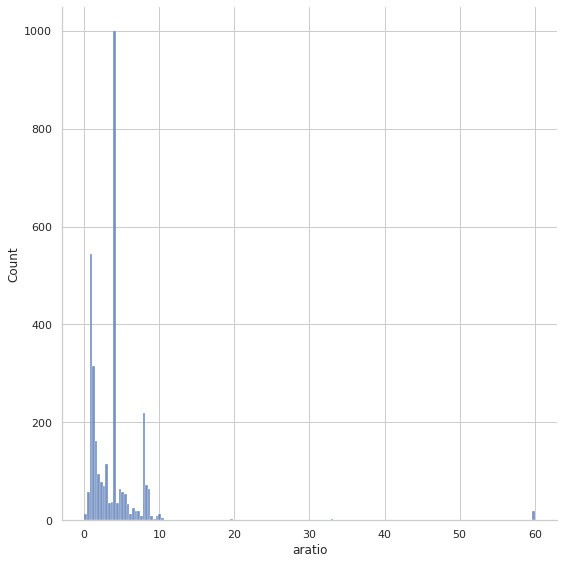

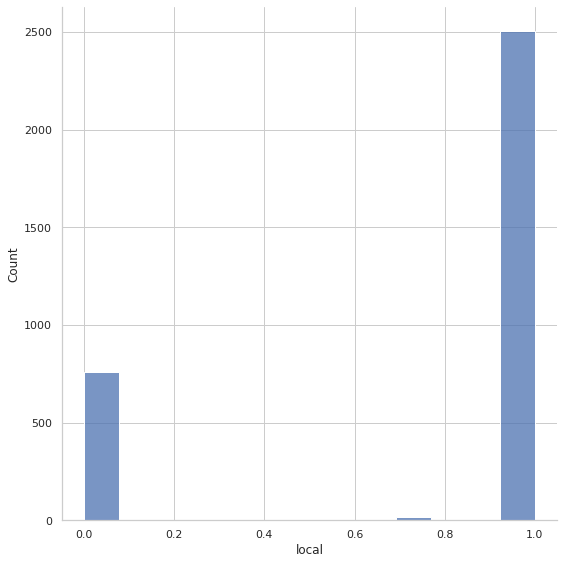

In [15]:
sns.displot(internetAd, x=internetAd.height, height=8)
sns.displot(internetAd, x=internetAd.width, height=8)
sns.displot(internetAd, x=internetAd.aratio, height=8)
sns.displot(internetAd, x=internetAd.local, height=8)

Question 3.2: You have noticed the wide variation across the different features. As a result, let's normalize the features using [MinMaxScalar](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.MinMaxScaler.html) method. Before we do that, we need to split the data into training and testing.

In [16]:
from sklearn.model_selection import train_test_split

X = internetAd[["height","width","aratio","local"]]
y = internetAd[["Target"]]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

In [17]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
scaler.fit(X_train,y_train)
X_train_minmax_scaled = scaler.transform(X_train)
X_test_minmax_scaled = scaler.transform(X_test)

Question 3.3: Lets build another training set where features are normalized using [StandardScalar](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html).

In [18]:
from sklearn.preprocessing import StandardScaler

sscaler = StandardScaler()
sscaler.fit(X_train,y_train)
X_train_standard_scaled = sscaler.transform(X_train)
X_test_standard_scaled = sscaler.transform(X_test)

Question 4.1: Apply [LogisticRegression](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html) to the above minmax scaled dataset with class_weight='balanced', solver='saga', and max_iter=1000. Calculate Accuracy, Confusion Matrix, Precision, and Recall.

In [19]:
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression(random_state=0,class_weight='balanced', solver='saga',max_iter=1000).fit(X_train_minmax_scaled, np.ravel(y_train))

In [20]:
from sklearn.metrics import confusion_matrix, classification_report
y_true, y_pred = y_test, lr.predict(X_test_minmax_scaled)
print("confusion matrix:\n",confusion_matrix(y_true, y_pred))
print("The mean accuracy score for this logistic regression model with the test data is {}%.".format(round(lr.score(X_test_minmax_scaled,y_test)*100,2)))
print(classification_report(y_true, y_pred,target_names=["nonad","ad"]))

confusion matrix:
 [[800 116]
 [ 75  92]]
The mean accuracy score for this logistic regression model with the test data is 82.36%.
              precision    recall  f1-score   support

       nonad       0.91      0.87      0.89       916
          ad       0.44      0.55      0.49       167

    accuracy                           0.82      1083
   macro avg       0.68      0.71      0.69      1083
weighted avg       0.84      0.82      0.83      1083



Question 4.2: Repeat question 4.1 setting penalty to {‘l1’,'l2', ‘elasticnet’}. 
- Set C=0.1 for l1.
- Set l1_ratio=0.5 for elasticnet.

In [21]:
#penalty='l1' , documentation says set l1_ratio=1 for penalty="l1"
lr = LogisticRegression(random_state=0,class_weight='balanced', solver='saga',max_iter=1000,penalty="l1",C=0.1).fit(X_train_minmax_scaled, np.ravel(y_train))


y_true, y_pred = y_test, lr.predict(X_test_minmax_scaled)
print("confusion matrix:\n",confusion_matrix(y_true, y_pred))
print("The mean accuracy score for this logistic regression model with the test data is {}%.".format(round(lr.score(X_test_minmax_scaled,y_test)*100,2)))
print(classification_report(y_true, y_pred,target_names=["nonad","ad"]))

confusion matrix:
 [[805 111]
 [ 71  96]]
The mean accuracy score for this logistic regression model with the test data is 83.19%.
              precision    recall  f1-score   support

       nonad       0.92      0.88      0.90       916
          ad       0.46      0.57      0.51       167

    accuracy                           0.83      1083
   macro avg       0.69      0.73      0.71      1083
weighted avg       0.85      0.83      0.84      1083



In [22]:
#penalty='l2'
lr = LogisticRegression(random_state=0,class_weight='balanced', solver='saga',max_iter=1000,penalty="l2").fit(X_train_minmax_scaled, np.ravel(y_train))


y_true, y_pred = y_test, lr.predict(X_test_minmax_scaled)
print("confusion matrix:\n",confusion_matrix(y_true, y_pred))
print("The mean accuracy score for this logistic regression model with the test data is {}%.".format(round(lr.score(X_test_minmax_scaled,y_test)*100,2)))
print(classification_report(y_true, y_pred,target_names=["nonad","ad"]))

confusion matrix:
 [[800 116]
 [ 75  92]]
The mean accuracy score for this logistic regression model with the test data is 82.36%.
              precision    recall  f1-score   support

       nonad       0.91      0.87      0.89       916
          ad       0.44      0.55      0.49       167

    accuracy                           0.82      1083
   macro avg       0.68      0.71      0.69      1083
weighted avg       0.84      0.82      0.83      1083



In [23]:
#penalty='elasticnet'
lr = LogisticRegression(random_state=0,class_weight='balanced', solver='saga',max_iter=1000,penalty="elasticnet",l1_ratio=0.5).fit(X_train_minmax_scaled, np.ravel(y_train))


y_true, y_pred = y_test, lr.predict(X_test_minmax_scaled)
print("confusion matrix:\n",confusion_matrix(y_true, y_pred))
print("The mean accuracy score for this logistic regression model with the test data is {}%.".format(round(lr.score(X_test_minmax_scaled,y_test)*100,2)))
print(classification_report(y_true, y_pred,target_names=["nonad","ad"]))

confusion matrix:
 [[805 111]
 [ 76  91]]
The mean accuracy score for this logistic regression model with the test data is 82.73%.
              precision    recall  f1-score   support

       nonad       0.91      0.88      0.90       916
          ad       0.45      0.54      0.49       167

    accuracy                           0.83      1083
   macro avg       0.68      0.71      0.69      1083
weighted avg       0.84      0.83      0.83      1083



Question 5: How do the three models compare? How did you make the comparison?

#### Their performances are all very comparable, using the score as an accuracy we can see that they're all within a percentage point of eachother. Looking more closely at the classification reports we can see the scores for ad and nonad are also comparable across the three models, what's interesting to me is that the score for nonad is consistently better than that for ad across all models. We can also look to precision as a another way of comparing the performances and again, they're all very comprable but also the nonad scores here are higher than that for ad. Lastly, the model that performs the best, though the margin is small, would be the one that use l2 as the penalty.

Question 6: Repeat steps 4.1-4.3 with the standard scaled dataset

In [25]:
#penalty='l1' 
lr = LogisticRegression(random_state=0,class_weight='balanced', solver='saga',max_iter=1000,penalty="l1",C=0.1).fit(X_train_standard_scaled, np.ravel(y_train))
y_true, y_pred = y_test, lr.predict(X_test_standard_scaled)
print("confusion matrix:\n",confusion_matrix(y_true, y_pred))
print("The mean accuracy score for this logistic regression model with the test data is {}%.".format(round(lr.score(X_test_standard_scaled,y_test)*100,2)))
print(classification_report(y_true, y_pred,target_names=["nonad","ad"]))

confusion matrix:
 [[797 119]
 [ 76  91]]
The mean accuracy score for this logistic regression model with the test data is 81.99%.
              precision    recall  f1-score   support

       nonad       0.91      0.87      0.89       916
          ad       0.43      0.54      0.48       167

    accuracy                           0.82      1083
   macro avg       0.67      0.71      0.69      1083
weighted avg       0.84      0.82      0.83      1083



In [26]:
#penalty='l2'
lr = LogisticRegression(random_state=0,class_weight='balanced', solver='saga',max_iter=1000,penalty="l2").fit(X_train_standard_scaled, np.ravel(y_train))
y_true, y_pred = y_test, lr.predict(X_test_standard_scaled)
print("confusion matrix:\n",confusion_matrix(y_true, y_pred))
print("The mean accuracy score for this logistic regression model with the test data is {}%.".format(round(lr.score(X_test_standard_scaled,y_test)*100,2)))
print(classification_report(y_true, y_pred,target_names=["nonad","ad"]))

confusion matrix:
 [[800 116]
 [ 75  92]]
The mean accuracy score for this logistic regression model with the test data is 82.36%.
              precision    recall  f1-score   support

       nonad       0.91      0.87      0.89       916
          ad       0.44      0.55      0.49       167

    accuracy                           0.82      1083
   macro avg       0.68      0.71      0.69      1083
weighted avg       0.84      0.82      0.83      1083



In [27]:
#penalty='elasticnet'
lr = LogisticRegression(random_state=0,class_weight='balanced', solver='saga',max_iter=1000,penalty="elasticnet",l1_ratio=0.5).fit(X_train_standard_scaled, np.ravel(y_train))
y_true, y_pred = y_test, lr.predict(X_test_standard_scaled)
print("confusion matrix:\n",confusion_matrix(y_true, y_pred))
print("The mean accuracy score for this logistic regression model with the test data is {}%.".format(round(lr.score(X_test_standard_scaled,y_test)*100,2)))
print(classification_report(y_true, y_pred,target_names=["nonad","ad"]))

confusion matrix:
 [[800 116]
 [ 75  92]]
The mean accuracy score for this logistic regression model with the test data is 82.36%.
              precision    recall  f1-score   support

       nonad       0.91      0.87      0.89       916
          ad       0.44      0.55      0.49       167

    accuracy                           0.82      1083
   macro avg       0.68      0.71      0.69      1083
weighted avg       0.84      0.82      0.83      1083

